* **Tran Anh Chuong** - V202401566
* **Homework 1**

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv('ikea_data.csv')
df.head()

,...1,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, 74x60 cm",Marcus Arvonen,60.0,43.0,74.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ...1               3694 non-null   int64  
 1   item_id            3694 non-null   int64  
 2   name               3694 non-null   object 
 3   category           3694 non-null   object 
 4   price              3694 non-null   float64
 5   old_price          3694 non-null   object 
 6   sellable_online    3694 non-null   bool   
 7   link               3694 non-null   object 
 8   other_colors       3694 non-null   object 
 9   short_description  3694 non-null   object 
 10  designer           3551 non-null   object 
 11  depth              2231 non-null   float64
 12  height             2706 non-null   float64
 13  width              3105 non-null   float64
dtypes: bool(1), float64(4), int64(2), object(7)
memory usage: 378.9+ KB


## **Task 1: Converting prices to USD**

In [51]:
data = df.assign(price_usd = df['price']*0.27)
csv = data.loc[:, ['price','price_usd']]
csv.head(10)

,price,price_usd
0,265.0,71.55
1,995.0,268.65
2,2095.0,565.65
3,69.0,18.63
4,225.0,60.75
5,345.0,93.15
6,129.0,34.83
7,195.0,52.65
8,129.0,34.83
9,2176.0,587.52


## **Task 2: Splitting multiple designers into separate rows**

In [52]:
#Validate for rows contain multiple designers
data['designer'].unique()

array(['Nicholai Wiig Hansen', 'Francis Cayouette', 'Henrik Preutz',
       'Marcus Arvonen', 'Carina Bengs', 'K Hagberg/M Hagberg',
       'Sarah Fager', 'Ehlén Johansson', 'Nike Karlsson',
       'Maja Ganszyniec', 'Karl Malmvall',
       'John/Jonas/Petrus/Paul/Caroline', 'Nike Karlsson/Maja Ganszyniec',
       'J Karlsson/N Karlsson', 'IKEA of Sweden/Karl Malmvall',
       'IKEA of Sweden', 'Nike Karlsson/J Karlsson/N Karlsson',
       'Ola Wihlborg', 'IKEA of Sweden/Tina Christensen',
       'IKEA of Sweden/K Hagberg/M Hagberg',
       'Ola Wihlborg/IKEA of Sweden', nan,
       'IKEA of Sweden/Ebba Strandmark',
       'K Hagberg/M Hagberg/IKEA of Sweden', 'Jon Karlsson',
       'IKEA of Sweden/Carina Bengs', 'David Wahl',
       'Jon Karlsson/IKEA of Sweden', 'IKEA of Sweden/Paulin Machado',
       'IKEA of Sweden/Eva Lilja Löwenhielm',
       'IKEA of Sweden/Synnöve Mork/Ola Wihlborg',
       'IKEA of Sweden/David Wahl', 'Ebba Strandmark/IKEA of Sweden',
       'Eva Lilja Löwenhi

The designer column may contain multiple designers separated by /.
✅ Transform the dataset so that each designer appears in a separate row with the same item details


In [53]:
# Step 1: Split the 'designer' string by '/' into a list of strings
data['designer'] = data['designer'].str.split('/')
# Step 2: Explode the 'designer' column so each item in the list gets its own row
data = data.explode('designer')
# Step 3: Strip any extra spaces around the designer names
data['designer'] = data['designer'].str.strip()
# Display the result to confirm it worked!
data.head(11)

,...1,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width,price_usd
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0,71.55
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0,268.65
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN,565.65
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0,18.63
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, 74x60 cm",Marcus Arvonen,60.0,43.0,74.0,60.75
5,5,10122647,INGOLF,Bar furniture,345.0,No old price,True,https://www.ikea.com/sa/en/p/ingolf-bar-stool-...,No,"Bar stool with backrest, 63 cm",Carina Bengs,45.0,91.0,40.0,93.15
6,6,70404875,FRANKLIN,Bar furniture,129.0,No old price,True,https://www.ikea.com/sa/en/p/franklin-bar-stoo...,No,"Bar stool with backrest, foldable, 63 cm",K Hagberg,44.0,95.0,50.0,34.83
6,6,70404875,FRANKLIN,Bar furniture,129.0,No old price,True,https://www.ikea.com/sa/en/p/franklin-bar-stoo...,No,"Bar stool with backrest, foldable, 63 cm",M Hagberg,44.0,95.0,50.0,34.83
7,7,60155602,DALFRED,Bar furniture,195.0,No old price,True,https://www.ikea.com/sa/en/p/dalfred-bar-stool...,No,"Bar stool, 63-74 cm",Sarah Fager,50.0,NaN,50.0,52.65
8,8,50406465,FRANKLIN,Bar furniture,129.0,No old price,True,https://www.ikea.com/sa/en/p/franklin-bar-stoo...,No,"Bar stool with backrest, foldable, 63 cm",K Hagberg,44.0,95.0,50.0,34.83


## **Task 3: Get Top 20 Designers by Number of Items**

Based on the dataset from Task 2, find the top 20 designers with the most products.
✅ Exclude "IKEA of Sweden" and remove missing values from the designer column.

In [54]:
top_designer = data.groupby('designer').size().nlargest(5).reset_index(name='num_items')
top_designer.head()

,designer,num_items
0,IKEA of Sweden,1502
1,Ehlén Johansson,394
2,Francis Cayouette,217
3,Ola Wihlborg,210
4,K Hagberg,195


* **1. Top 3 designers are Ehlen Johansson (394) and Francis Cayouette (217) and Ola Wihlborg (210)**
* **2. Number of items designed by IKEA of Sweden is 1502**
* **3. We should exclude IKEA of Sweden since it represents the organization instead of individual designer, thus we can avoid bias**

In [57]:
top_designer = data.dropna(subset=['designer'])
top_designer = top_designer[top_designer['designer'] != 'IKEA of Sweden']
top_designer = top_designer.groupby('designer').size().nlargest(3).reset_index(name='num_items')
top_designer.head()

,designer,num_items
0,Ehlén Johansson,394
1,Francis Cayouette,217
2,Ola Wihlborg,210


# **Task 4: Price Distribution per Designer (Box Plot)**

✅ Create a box plot showing the distribution of item prices (USD) for the top designers identified in Task 3.

C:\Users\jimmy\AppData\Local\Temp\ipykernel_36760\709338188.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


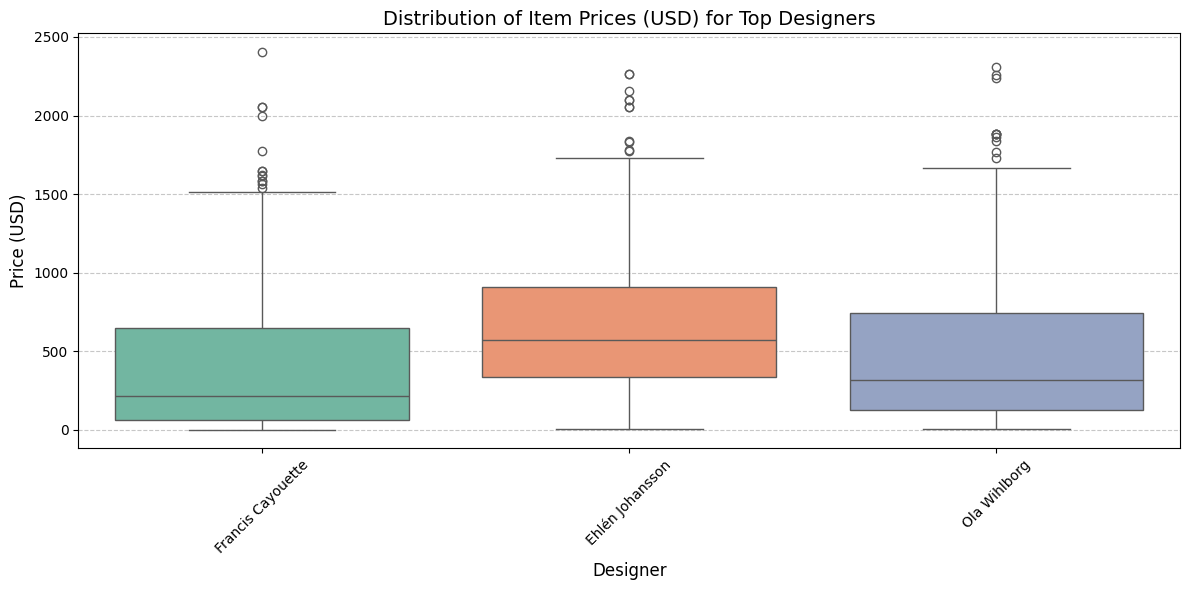

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. We need the list of the top designers' names from Task 3
top_designer_names = top_designer['designer'].tolist()

# 2. Filter the main dataset (`data` from Task 1 which has 'price_usd') 
# to only include rows where the designer is in our top designers list
top_designer_data = data[data['designer'].isin(top_designer_names)]

# 3. Create the box plot using Seaborn for beautiful default styling
plt.figure(figsize=(12, 6))

# We use seaborn's boxplot, mapping designer to x and price_usd to y
sns.boxplot(
    data=top_designer_data, 
    x='designer', 
    y='price_usd', 
    palette='Set2' # A nice built-in color palette
)

# 4. Add labels and a title to make it professional
plt.title('Distribution of Item Prices (USD) for Top Designers', fontsize=14)
plt.xlabel('Designer', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# Rotate the x-axis labels so the designers' names don't overlap
plt.xticks(rotation=45)

# Show the plot cleanly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* **Key findings:** Ehlen product's price is higher than the other two indicating this designer's level, median is roughly $600. Francis and Ola share similar distribution in price; Francis's product is the most budget-friendly with the median of around under $250. Ola has the greatest variety in the market, the median is around $300 and the box is higher depicting a wider spread in the middle 50% of the catalog. Alll three designers have an amount of outlier products ranging above $1500 to around $2200. 3 designers have median price close to the bottom of the box. 
* **For me this is a relatively effective visualization. I think we can add a median number for each boxes for a quick overview.**

## **Task 5: Distribution of Items per Category (Lollipop Chart)**

✅ Count the number of items in each furniture category and visualize the distribution using a lollipop chart.
* X-axis: Categories
* Y-axis: Number of items

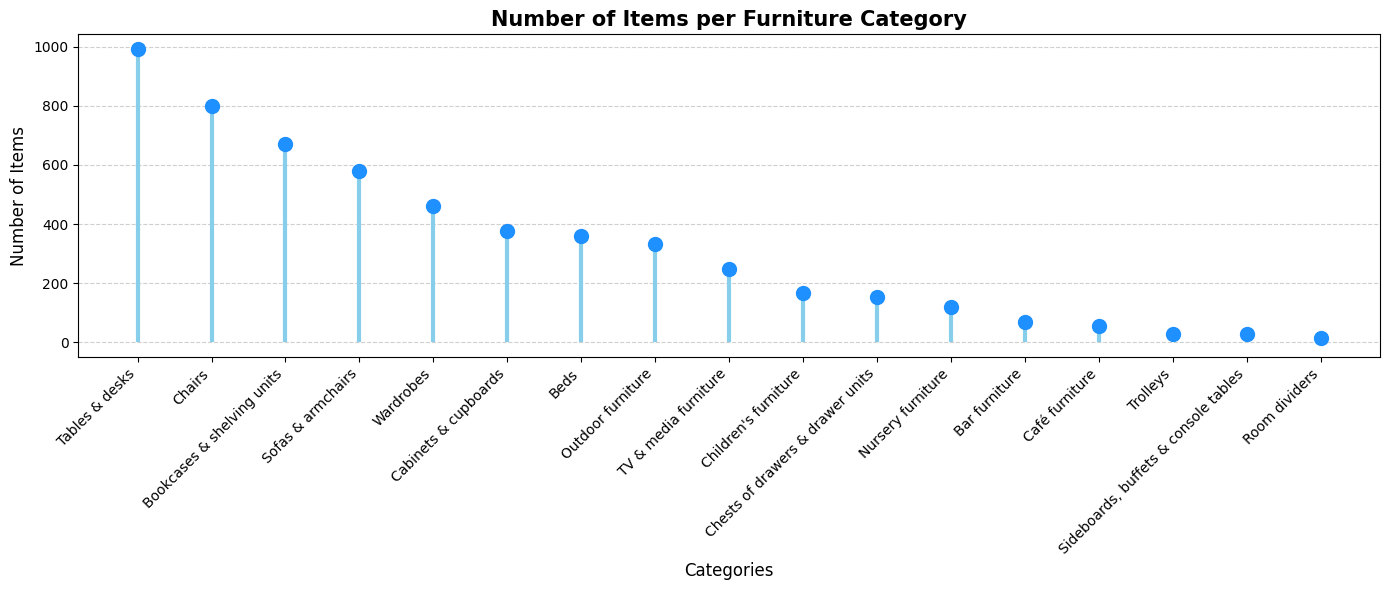

In [60]:
# 1. Count the number of items in each furniture category
# reset_index() converts the resulting Series back into a DataFrame
category_counts = data['category'].value_counts().reset_index()
category_counts.columns = ['category', 'num_items']

# 2. Create the figure for the plot
plt.figure(figsize=(14, 6))

# 3. Create the Lollipop Chart
# A lollipop chart is essentially a vertical line connected to a scatter dot!
# The 'vlines' draw the stems
plt.vlines(
    x=category_counts['category'], 
    ymin=0, 
    ymax=category_counts['num_items'], 
    color='skyblue', 
    linewidth=3
)

# The 'scatter' draws the candy on top
plt.scatter(
    x=category_counts['category'], 
    y=category_counts['num_items'], 
    color='dodgerblue', 
    s=100, # Size of the dots
    zorder=3 # Ensures the dots render on top of gridlines/stems
)

# 4. Add formatting and labels
plt.title('Number of Items per Furniture Category', fontsize=15, fontweight='bold')
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)

# Rotate the category names so they don't overlap
plt.xticks(rotation=45, ha='right')

# Add a light background grid for easy reading
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Display the plot
plt.tight_layout()
plt.show()

* **Most common categories:** Tables & desks (around 1000) followed by Chairs (approx 800)
* **We can add exact number for each categories, change the diagram to horizontal view since the categories name are quite long (45 deg rotation can cause inconvinience)**

## **Task 6: Average Price per Category**

✅ Calculate the average price (USD) per furniture category and visualize the distribution using a lollipop chart.
* X-axis: Categories
* Y-axis: Average price in USD

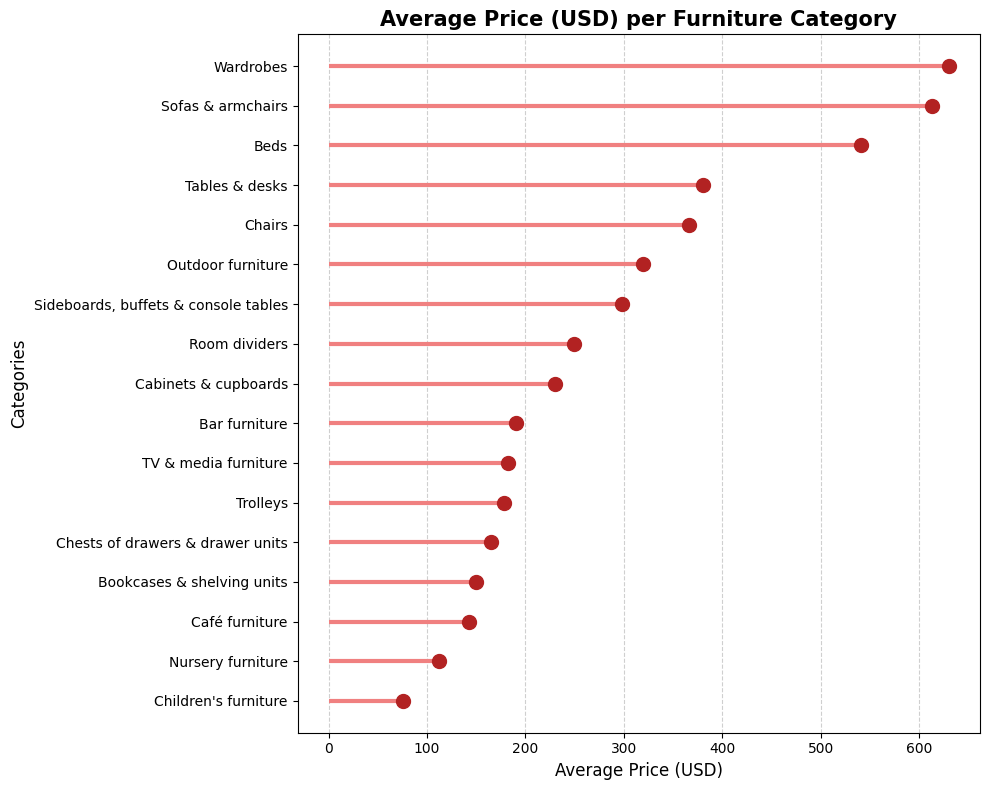

In [ ]:
# 1. Calculate the average price (USD) per furniture category
# We group by 'category', find the mean of 'price_usd', and sort ascending 
# so the highest value appears at the top of the horizontal chart!
avg_price_cat = data.groupby('category')['price_usd'].mean().sort_values(ascending=True).reset_index()

# 2. Create the figure for the plot
plt.figure(figsize=(10, 8))

# 3. Create the Horizontal Lollipop Chart
# plt.hlines() draws the horizontal stems
plt.hlines(
    y=avg_price_cat['category'], 
    xmin=0, 
    xmax=avg_price_cat['price_usd'], 
    color='lightcoral', 
    linewidth=3
)

# plt.scatter() draws the candy on the right side!
plt.scatter(
    x=avg_price_cat['price_usd'], 
    y=avg_price_cat['category'], 
    color='firebrick', 
    s=100, 
    zorder=3 # Ensures the dots render clearly on top of grid lines
)

# 4. Add formatting and titles
plt.title('Average Price (USD) per Furniture Category', fontsize=15, fontweight='bold')
plt.xlabel('Average Price (USD)', fontsize=12)
plt.ylabel('Categories', fontsize=12)

# Add a clean background grid on the x-axis to make values easy to read
plt.grid(axis='x', linestyle='--', alpha=0.6, zorder=0)

# Render everything nicely
plt.tight_layout()
plt.show()


* **Most expensive furniture categories:** Wardrobes, Sofas & armchairs, Beds with the price of around $630, $610 and $530 respectively.
* **Cheapest furniture categories:** Children's furniture (~$80), Nursery furniture (~$105) and cafe furniture (~$140)  
* **Suprising findings:** Although Tables & desks among the top 5 most expensive items, they are the most common items in the previous analysis. This suggests that while they are high-volume, they aren't necessarily "cheap" filler items.

## **Task 7: Price vs. Volume Relationship (Scatter Plot)**

✅ Calculate the volume of each item using:
Volume=Height×Width×Depth\text{Volume} = \text{Height} \times \text{Width} \times \text{Depth}Volume=Height×Width×Depth
✅ Create a scatter plot showing the relationship between price (USD) and volume.
* X-axis: Price (USD)
* Y-axis: Volume
* Color: Category

In [65]:
test = data.loc[:, ['height', 'width', 'depth']]
test.head()

,height,width,depth
0,99.0,51.0,NaN
1,105.0,80.0,NaN
2,NaN,NaN,NaN
3,100.0,60.0,50.0
4,43.0,74.0,60.0


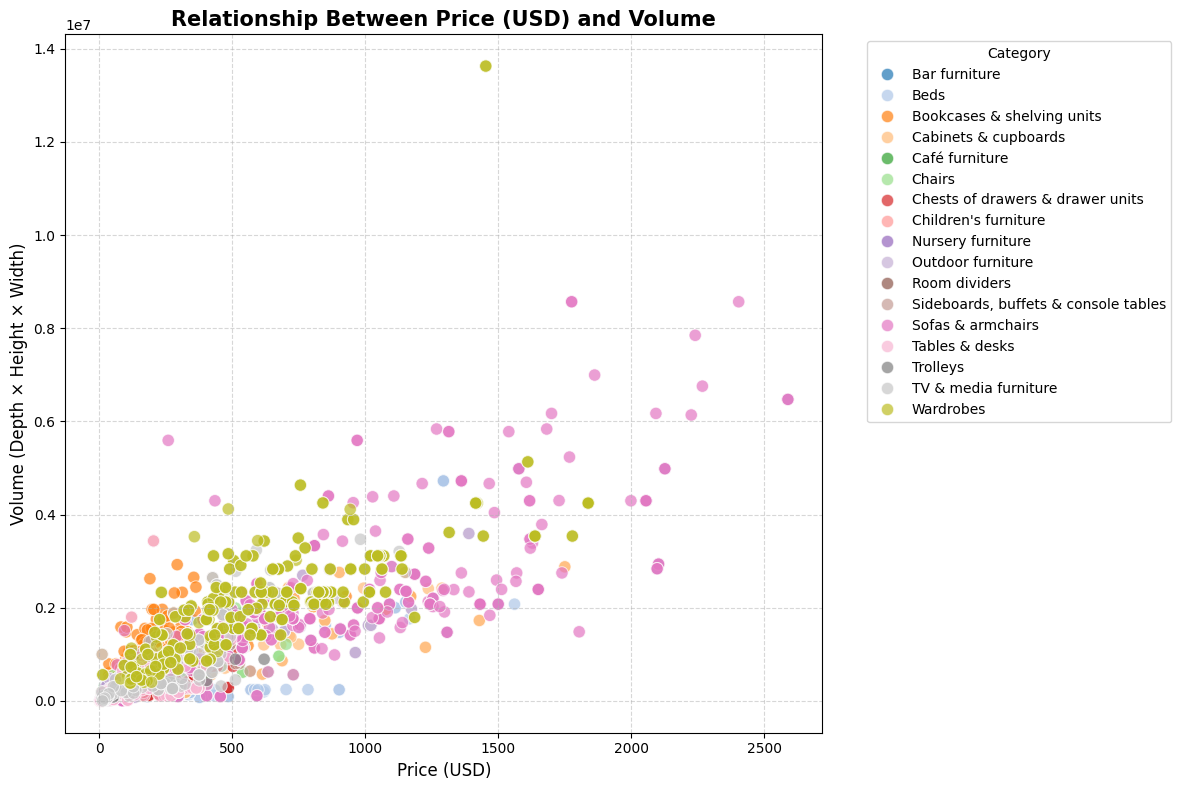

In [64]:
# 1. Reset the index to fix duplicate labels from Task 2, then calculate volume
data = data.reset_index(drop=True)
data['volume'] = data['depth'] * data['height'] * data['width']

# 2. Create the figure for the scatter plot
plt.figure(figsize=(12, 8))

# 3. Create the Scatter Plot using Seaborn
# x='price_usd', y='volume', hue='category' colors it by category automatically
sns.scatterplot(
    data=data,
    x='price_usd',
    y='volume',
    hue='category',
    palette='tab20',   # A nice color palette with distinct colors
    alpha=0.7,         # Make dots slightly transparent so overlapping points are visible
    s=80               # Adjust dot size to be easier to see
)

# 4. Add titles and formatting
plt.title('Relationship Between Price (USD) and Volume', fontsize=15, fontweight='bold')
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Volume (Depth × Height × Width)', fontsize=12)

# Position the legend outside the plot so it doesn't cover up our data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category')

# 5. Bring in the visual polish
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout() # This forces the plot to fit nicely considering the external legend
plt.show()


* **1. Are larger items always more expensive?** No, larger items are not always more expensive. While there is a general upward trend—meaning that as volume increases, price tends to increase—the relationship is quite "noisy" and far from a perfect linear correlation. Materials and Complexity: A small item made of premium materials (like a designer chair or a high-end electronics console) can easily outprice a massive but simple item (like a basic particle-board wardrobe). The "Luxury Small" items: If you look at the bottom-right of the plot, there are several dots representing relatively small items (low volume) that cost between $1,500 and $2,500. The "Massive Value" items: Conversely, toward the middle-top, there are very large items priced under $1,000.
* **2. Key trends:** General Positive Correlation: There is a "cone-shaped" distribution. At lower prices ($0–$500), volume is generally low. As you move toward the $2,000+ range, the items generally occupy a higher volume (mostly pink dots representing Sofas & armchairs).
* **3. Improvement:** With 17 categories, the legend is overwhelming. It would be much more effective to create 17 small sub-plots (one for each category). This would allow you to see the specific price-to-volume relationship for "Beds" vs. "Chairs" without the dots overlapping.

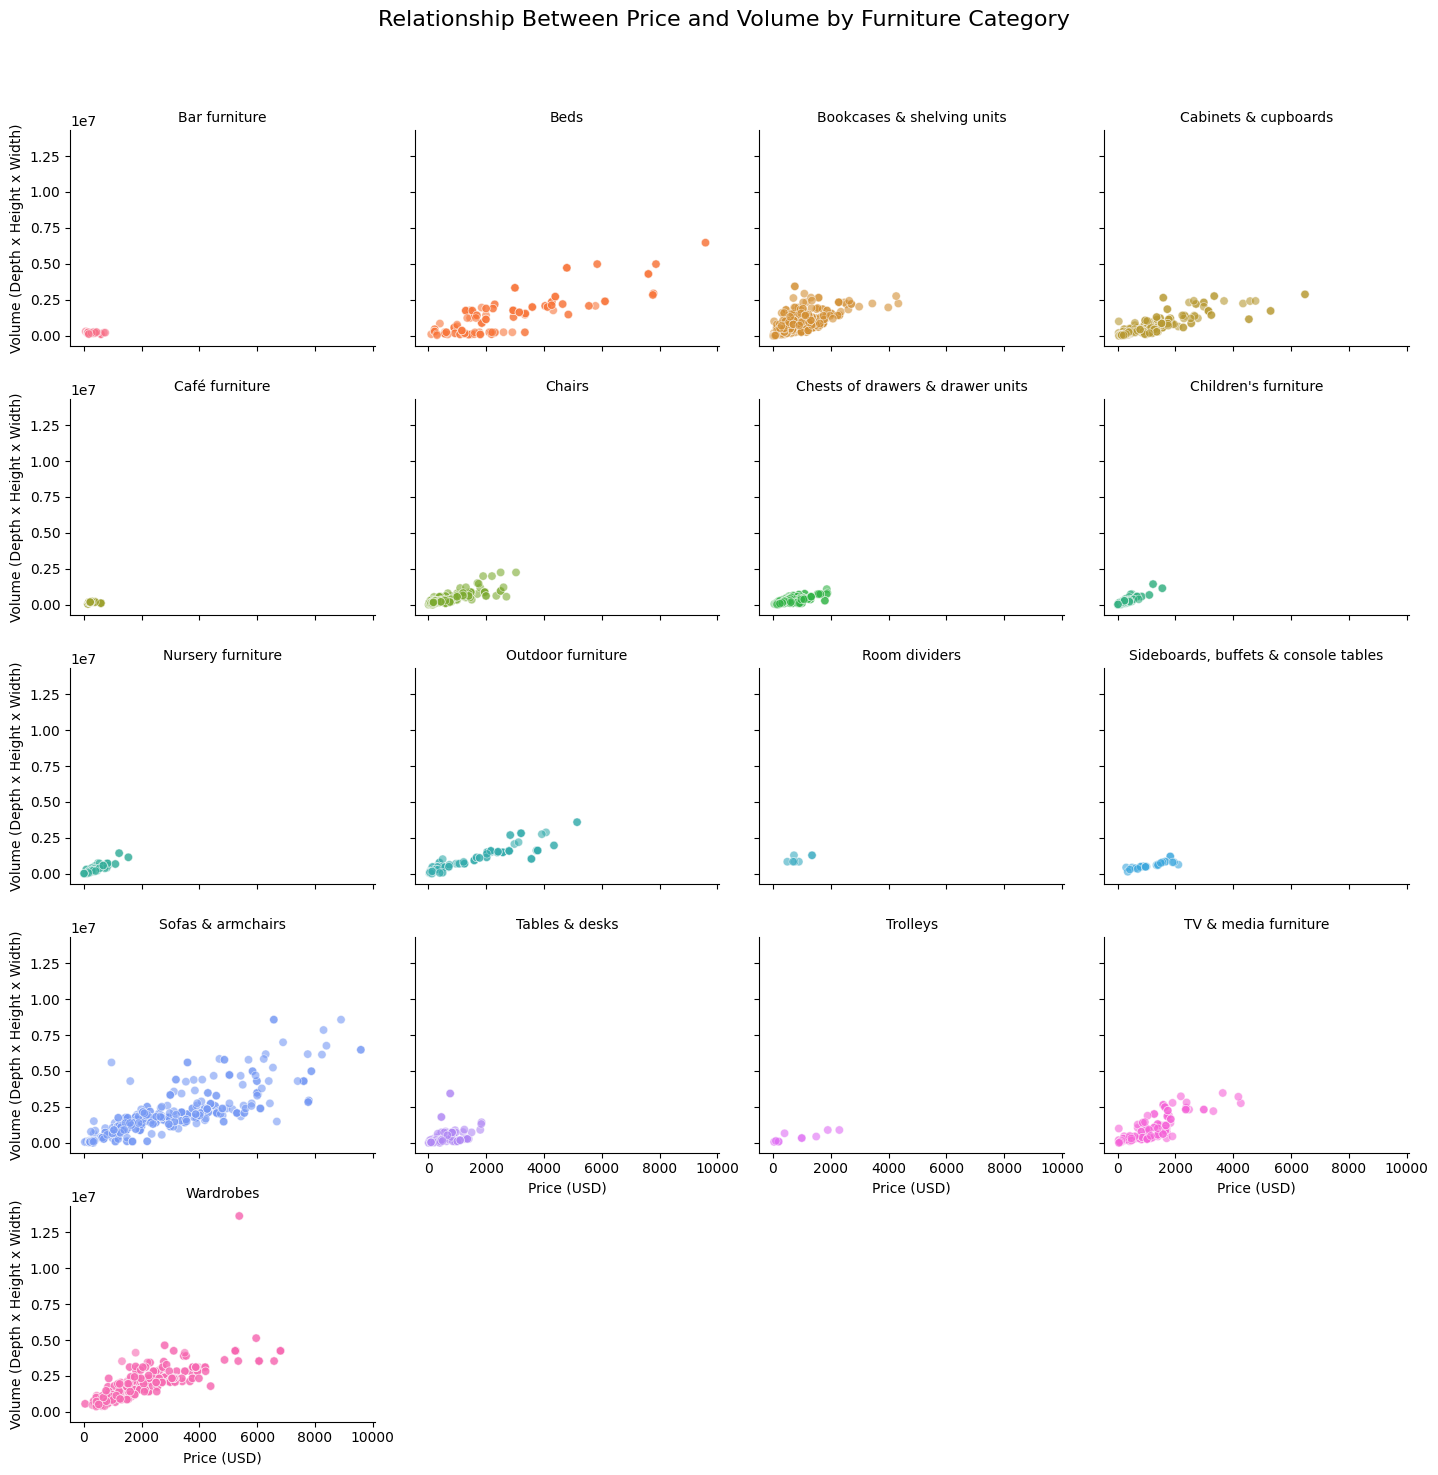

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
# (Replace with the path to your local 'ikea.csv' file)

# Calculate Volume
data['volume'] = data['depth'] * data['height'] * data['width']

# Create a faceted scatter plot using Seaborn's relplot
g = sns.relplot(
    data=data,
    x="price", y="volume",
    col="category", hue="category",
    col_wrap=4,        # Number of columns in the grid
    height=3, aspect=1.2,
    kind="scatter", alpha=0.6, legend=False
)

# Improve labels and add a main title
g.set_axis_labels("Price (USD)", "Volume (Depth x Height x Width)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Relationship Between Price and Volume by Furniture Category", fontsize=16)

# Save the plot
plt.savefig('faceted_price_volume_plot.png', bbox_inches='tight')